# PaySim Fraud Detection Notebook

This notebook is the presentation layer for the PaySim-first fraud-detection pipeline.
The `.py` modules under `spark/` remain the source of truth.

Goals:
- explore the raw PaySim dataset with Spark
- inspect data quality and label imbalance
- reuse the shared preprocessing helpers from `spark/preprocessing.py`
- train and compare the candidate models defined in `spark/train_model.py`

Important note: all heavy processing stays in Spark. Small collected results are used only for plots.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

if Path('/opt/spark/work').exists():
    REPO_ROOT = Path('/opt/spark/work')
else:
    REPO_ROOT = Path.cwd().resolve()
    if REPO_ROOT.name == 'notebooks':
        REPO_ROOT = REPO_ROOT.parent

SPARK_DIR = REPO_ROOT / 'spark'
if str(SPARK_DIR) not in sys.path:
    sys.path.insert(0, str(SPARK_DIR))

DATA_PATH = REPO_ROOT / 'data' / 'paysim_transactions.csv'

spark = (
    SparkSession.builder
    .appName('PaySim-EDA-Training-Notebook')
    .config('spark.sql.adaptive.enabled', 'true')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')

print(f'Repo root: {REPO_ROOT}')
print(f'Dataset path: {DATA_PATH}')

Repo root: D:\Ki2Nam4\BigData\Brainstorm\fraud-detection-pipeline
Dataset path: D:\Ki2Nam4\BigData\Brainstorm\fraud-detection-pipeline\data\paysim_transactions.csv


## 1. Load the full PaySim dataset with Spark

This step uses the full CSV through Spark instead of loading it into Pandas.

In [2]:
raw_df = spark.read.csv(str(DATA_PATH), header=True, inferSchema=True)
raw_count = raw_df.count()

print(f'Raw rows: {raw_count:,}')
raw_df.printSchema()
raw_df.show(5, truncate=False)

Raw rows: 6,362,620
root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|type    |amount  |nameOrig   |oldbalanceOrg|newbalanceOrig|nameDest   |oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|1   |PAYMENT |9839.64 |C1231006815|170136.0     |160296.36     |M1979787155|0.0           |0.0           |0      |0    

## 2. Data quality and label distribution

We inspect null counts, transaction-type distribution, and the fraud-rate imbalance before cleaning.

In [3]:
quality_columns = [
    'step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg',
    'newbalanceOrig', 'nameDest', 'oldbalanceDest',
    'newbalanceDest', 'isFraud', 'isFlaggedFraud'
]
null_exprs = [
    F.sum(F.when(F.col(column_name).isNull(), 1).otherwise(0)).alias(column_name)
    for column_name in quality_columns
]

raw_df.select(null_exprs).show(truncate=False)
raw_df.groupBy('type').count().orderBy('type').show()
raw_df.groupBy('type').agg(
    F.sum('isFraud').alias('fraud_count'),
    F.avg('amount').alias('avg_amount')
).orderBy('type').show()
raw_df.agg((F.avg('isFraud') * 100).alias('fraud_rate_percent')).show()

+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|0   |0   |0     |0       |0            |0             |0       |0             |0             |0      |0             |
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+

+--------+-------+
|    type|  count|
+--------+-------+
| CASH_IN|1399284|
|CASH_OUT|2237500|
|   DEBIT|  41432|
| PAYMENT|2151495|
|TRANSFER| 532909|
+--------+-------+

+--------+-----------+------------------+
|    type|fraud_count|        avg_amount|
+--------+-----------+------------------+
| CASH_IN|          0|168920.24200409584|
|CASH_OUT|       4116|176273.96434614208|
|   DEBIT|          0|

## 3. Small visual summaries

Only small aggregated results are collected for plotting.

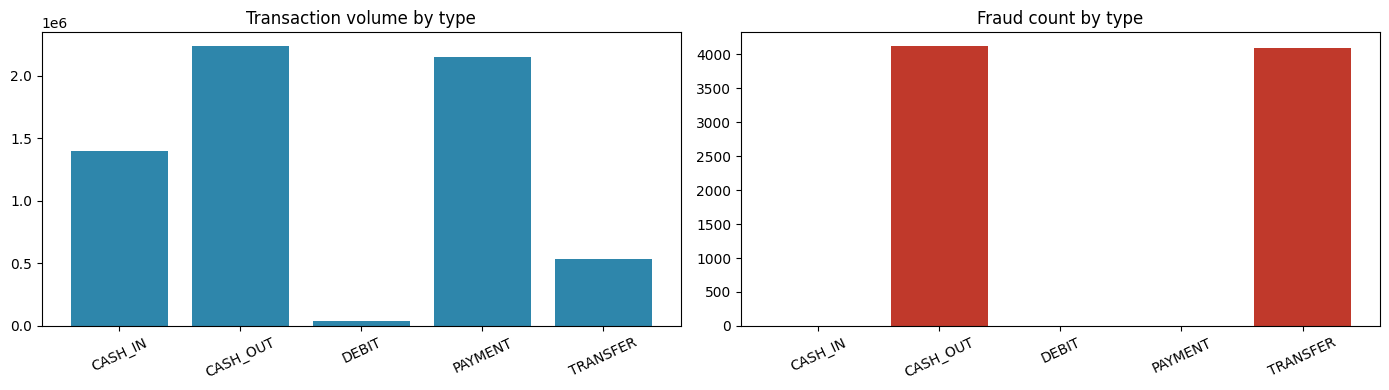

In [4]:
type_counts = raw_df.groupBy('type').count().orderBy('type').collect()
fraud_counts = raw_df.groupBy('type').agg(
    F.sum('isFraud').alias('fraud_count')
).orderBy('type').collect()

labels = [row['type'] for row in type_counts]
counts = [row['count'] for row in type_counts]
frauds = [row['fraud_count'] for row in fraud_counts]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(labels, counts, color='#2E86AB')
axes[0].set_title('Transaction volume by type')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(labels, frauds, color='#C0392B')
axes[1].set_title('Fraud count by type')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 4. Shared preprocessing from `spark/preprocessing.py`

The notebook reuses the same helpers as the training and streaming jobs.
That keeps notebook logic aligned with the deployed pipeline.

In [5]:
from preprocessing import clean_paysim_dataframe, prepare_dataframe

clean_df = clean_paysim_dataframe(raw_df)
prepared_df = prepare_dataframe(raw_df)

clean_count = clean_df.count()
print(f'Clean rows: {clean_count:,}')
print(f'Dropped rows: {raw_count - clean_count:,}')
print('Prepared columns:')
print(prepared_df.columns)

prepared_df.select(
    'type',
    'amount',
    'balance_diff_orig',
    'balance_diff_dest',
    'amount_ratio',
    'is_zero_balance_orig',
    'is_large_amount',
    'label'
).show(5, truncate=False)

Clean rows: 6,362,620
Dropped rows: 0
Prepared columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'label', 'isFlaggedFraud', 'balance_diff_orig', 'balance_diff_dest', 'amount_ratio', 'is_zero_balance_orig', 'is_large_amount']
+--------+--------+------------------+-----------------+--------------------+--------------------+---------------+-----+
|type    |amount  |balance_diff_orig |balance_diff_dest|amount_ratio        |is_zero_balance_orig|is_large_amount|label|
+--------+--------+------------------+-----------------+--------------------+--------------------+---------------+-----+
|PAYMENT |9839.64 |9839.640000000014 |0.0              |0.057833628193749737|0.0                 |0.0            |0.0  |
|PAYMENT |1864.28 |1864.2799999999988|0.0              |0.08773082352941176 |0.0                 |0.0            |0.0  |
|TRANSFER|181.0   |181.0             |0.0              |0.9945054945054945  |1.0         

## 5. Train and evaluate candidate models

The training script is still the source of truth. The notebook simply calls its helpers and visualizes the result.

In [6]:
import importlib
import train_model

importlib.reload(train_model)
from train_model import train_paysim, results_to_rows, select_best_model

training_results = train_paysim(spark, csv_path=str(DATA_PATH))
metrics_rows = results_to_rows(training_results)

for row in metrics_rows:
    print(row)

best_key, alt_key = select_best_model(training_results)
print(f'Best model key: {best_key}')
print(f'Alternate model key: {alt_key}')


PaySim dataset loading and preprocessing

Loading PaySim from /opt/spark/work/data/paysim_transactions.csv...


AnalysisException: [PATH_NOT_FOUND] Path does not exist: file:/opt/spark/work/data/paysim_transactions.csv.

In [ ]:
model_names = [row['model_name'] for row in metrics_rows]
validation_auc = [row['validation_auc'] for row in metrics_rows]
test_auc = [row['test_auc'] for row in metrics_rows]

x_positions = list(range(len(model_names)))

plt.figure(figsize=(8, 4))
plt.bar(
    [value - 0.15 for value in x_positions],
    validation_auc,
    width=0.3,
    label='Validation AUC',
    color='#117A65'
)
plt.bar(
    [value + 0.15 for value in x_positions],
    test_auc,
    width=0.3,
    label='Test AUC',
    color='#8E44AD'
)
plt.xticks(x_positions, model_names)
plt.ylim(0.0, 1.0)
plt.title('Candidate model comparison')
plt.legend()
plt.show()

## 6. Next step

When you want to deploy the best model into the runtime pipeline, run `spark/train_model.py` directly.
That script saves the selected model to `models/fraud_pipeline_model/`, which is the path consumed by the streaming job.

In [ ]:
# Optional cleanup when you are done with the notebook.
# spark.stop()